# ChestMNIST Feature-Fusion ANN Lite for Colab Free T4

A lighter and safer `Run All` notebook for Colab Free:
- memory-safe on-disk feature cache
- 3-fold multilabel CV instead of 5-fold
- lighter handcrafted features: raw + HOG + LBP histogram + intensity histogram
- weighted focal BCE
- Drive saving and zip download

In [1]:
import os
from pathlib import Path

IN_COLAB = 'COLAB_GPU' in os.environ
save_root = Path('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    preferred_roots = [
        Path('/content/drive/MyDrive/Colab Experiments/Lab3-LT'),
        Path('/content/drive/MyDrive/Lab3-LT'),
        Path('/content/drive/MyDrive/Colab Notebooks/Lab3-LT'),
    ]
    for candidate in preferred_roots:
        candidate.mkdir(parents=True, exist_ok=True)
        save_root = candidate
        break

artifact_dir = save_root / 'artifacts' / 'chestmnist_feature_fusion_ann_lite'
data_root = save_root / 'data' / 'chestmnist'
cache_dir = data_root / 'feature_fusion_lite_cache'
artifact_dir.mkdir(parents=True, exist_ok=True)
data_root.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)

print('save_root =', save_root)
print('artifact_dir =', artifact_dir)
print('cache_dir =', cache_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
save_root = /content/drive/MyDrive/Colab Experiments/Lab3-LT
artifact_dir = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_feature_fusion_ann_lite
cache_dir = /content/drive/MyDrive/Colab Experiments/Lab3-LT/data/chestmnist/feature_fusion_lite_cache


In [2]:
if IN_COLAB:
    !pip install -q medmnist scikit-learn matplotlib iterative-stratification scikit-image tqdm
    !nvidia-smi


Thu Mar 26 09:53:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             31W /   70W |     393MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import json
import random
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import medmnist
import numpy as np
import torch
import torch.nn as nn
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from medmnist import INFO
from sklearn.metrics import f1_score, roc_auc_score
from skimage.feature import hog, local_binary_pattern
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
NUM_FOLDS = 3
EPOCHS = 40
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-4
FOCAL_GAMMA = 2.0
THRESHOLD_GRID = np.linspace(0.10, 0.50, 9)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

def compute_feature_vector(image: np.ndarray) -> np.ndarray:
    img = image.astype(np.uint8)
    img_f = img.astype(np.float32) / 255.0
    raw = img_f.reshape(-1)

    hog_feat = hog(
        img_f,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True,
    ).astype(np.float32)

    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=np.arange(11), range=(0, 10), density=True)
    lbp_hist = lbp_hist.astype(np.float32)

    intensity_hist, _ = np.histogram(img, bins=16, range=(0, 256), density=True)
    intensity_hist = intensity_hist.astype(np.float32)

    return np.concatenate([raw, hog_feat, lbp_hist, intensity_hist]).astype(np.float32)

def build_feature_cache(images: np.ndarray, cache_path: Path, split_name: str) -> np.ndarray:
    meta_path = cache_path.with_suffix('.json')
    if cache_path.exists() and meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        shape = tuple(meta['shape'])
        print(f'Loading cached features for {split_name} from', cache_path)
        return np.memmap(cache_path, dtype=np.float32, mode='r', shape=shape)

    sample_dim = compute_feature_vector(images[0].squeeze()).shape[0]
    shape = (len(images), sample_dim)
    mmap = np.memmap(cache_path, dtype=np.float32, mode='w+', shape=shape)
    for i, image in enumerate(tqdm(images, desc=f'Extracting {split_name} features')):
        mmap[i] = compute_feature_vector(image.squeeze())
    mmap.flush()
    meta_path.write_text(json.dumps({'shape': list(shape)}), encoding='utf-8')
    return np.memmap(cache_path, dtype=np.float32, mode='r', shape=shape)

class FeatureDataset(Dataset):
    def __init__(self, features: np.ndarray, labels: np.ndarray) -> None:
        self.features = np.asarray(features, dtype=np.float32)
        self.labels = labels.astype(np.float32)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return torch.from_numpy(self.features[idx]), torch.from_numpy(self.labels[idx])

class LiteFusionANN(nn.Module):
    def __init__(self, input_dim: int, num_classes: int = 14) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.net(x)

class WeightedFocalBCEWithLogits(nn.Module):
    def __init__(self, pos_weight: torch.Tensor, gamma: float = 2.0) -> None:
        super().__init__()
        self.register_buffer('pos_weight', pos_weight)
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none', pos_weight=self.pos_weight)
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        return (((1 - pt) ** self.gamma) * bce).mean()

@dataclass
class EvalResult:
    loss: float
    macro_auc: float
    macro_f1: float
    acc: float
    y_true: np.ndarray
    y_prob: np.ndarray

def safe_macro_auc(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    aucs = []
    for i in range(y_true.shape[1]):
        if np.unique(y_true[:, i]).size < 2:
            continue
        aucs.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
    return float(np.mean(aucs)) if aucs else 0.0

def multilabel_acc(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray) -> float:
    y_pred = (y_prob >= thresholds[None, :]).astype(np.int32)
    return float((y_pred == y_true).mean())

def macro_f1_with_thresholds(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray) -> float:
    y_pred = (y_prob >= thresholds[None, :]).astype(np.int32)
    return float(np.mean([f1_score(y_true[:, i], y_pred[:, i], zero_division=0) for i in range(y_true.shape[1])]))

def evaluate(model, loader, criterion, thresholds=None):
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_true = []
    all_prob = []
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            total_loss += loss.item() * features.size(0)
            total_items += features.size(0)
            all_true.append(labels.cpu().numpy())
            all_prob.append(probs.cpu().numpy())
    y_true = np.concatenate(all_true, axis=0)
    y_prob = np.concatenate(all_prob, axis=0)
    if thresholds is None:
        thresholds = np.full(y_true.shape[1], 0.5, dtype=np.float32)
    return EvalResult(
        loss=total_loss / max(total_items, 1),
        macro_auc=safe_macro_auc(y_true, y_prob),
        macro_f1=macro_f1_with_thresholds(y_true, y_prob, thresholds),
        acc=multilabel_acc(y_true, y_prob, thresholds),
        y_true=y_true,
        y_prob=y_prob,
    )

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    total_items = 0
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * features.size(0)
        total_items += features.size(0)
    return total_loss / max(total_items, 1)

def tune_thresholds(y_true: np.ndarray, y_prob: np.ndarray) -> np.ndarray:
    thresholds = []
    for i in range(y_true.shape[1]):
        best_t = 0.5
        best_f1 = -1.0
        for t in THRESHOLD_GRID:
            pred = (y_prob[:, i] >= t).astype(np.int32)
            score = f1_score(y_true[:, i], pred, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_t = float(t)
        thresholds.append(best_t)
    return np.asarray(thresholds, dtype=np.float32)


device = cuda


In [4]:
info = INFO['chestmnist']
DataClass = getattr(medmnist, info['python_class'])

train_set = DataClass(split='train', download=True, root=str(data_root), size=28)
test_set = DataClass(split='test', download=True, root=str(data_root), size=28)

train_images = train_set.imgs
train_labels = train_set.labels.astype(np.float32)
test_images = test_set.imgs
test_labels = test_set.labels.astype(np.float32)
class_names = info['label']

train_cache = cache_dir / 'train_feature_fusion_lite.dat'
test_cache = cache_dir / 'test_feature_fusion_lite.dat'
train_features = build_feature_cache(train_images, train_cache, 'train')
test_features = build_feature_cache(test_images, test_cache, 'test')

print('train_features.shape =', train_features.shape)
print('test_features.shape =', test_features.shape)


Extracting train features:   0%|          | 0/78468 [00:00<?, ?it/s]

Extracting test features:   0%|          | 0/22433 [00:00<?, ?it/s]

train_features.shape = (78468, 2106)
test_features.shape = (22433, 2106)



===== Fold 1/3 =====
{"epoch": 1, "train_loss": 0.3349801582797147, "train_macro_auc": 0.7139531412779344, "train_acc": 0.6026615035064339, "val_loss": 0.30299376047228177, "val_macro_auc": 0.6884169807923929, "val_acc": 0.60309298057807}
{"epoch": 2, "train_loss": 0.2995913649329098, "train_macro_auc": 0.7521193557735717, "train_acc": 0.6460795665567037, "val_loss": 0.29729574002208176, "val_macro_auc": 0.7121842200290932, "val_acc": 0.6450527603609114}
{"epoch": 3, "train_loss": 0.2837274320210534, "train_macro_auc": 0.7643775059743335, "train_acc": 0.643300908832718, "val_loss": 0.30812302502511674, "val_macro_auc": 0.7135880942568326, "val_acc": 0.6419559565682826}
{"epoch": 4, "train_loss": 0.27902152203678593, "train_macro_auc": 0.7782863294938096, "train_acc": 0.657745832696131, "val_loss": 0.31116268851374573, "val_macro_auc": 0.7215260417827744, "val_acc": 0.6557495685229283}
{"epoch": 5, "train_loss": 0.26895945005450417, "train_macro_auc": 0.7961364247849589, "train_acc": 0

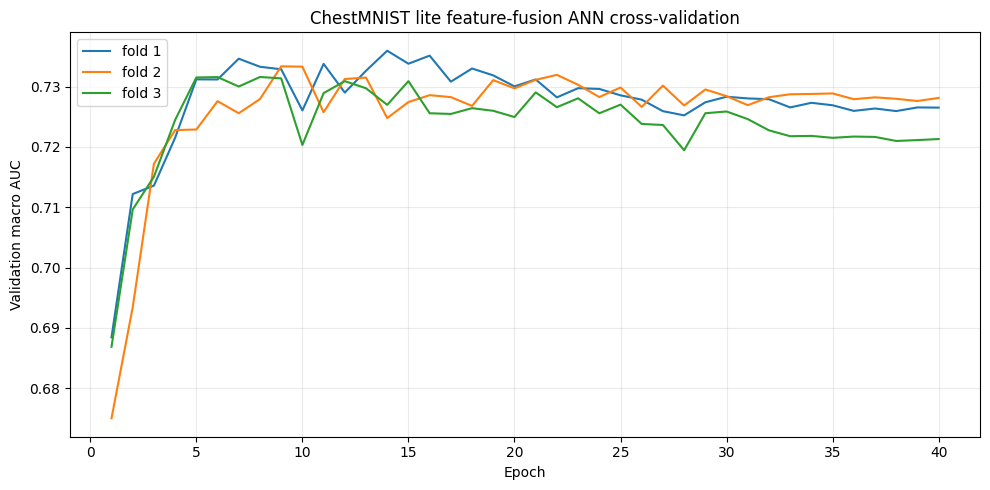

{
  "ensemble_test_macro_auc": 0.7424433173624205,
  "ensemble_test_acc_at_0_5": 0.7301265355248326,
  "ensemble_test_macro_f1_tuned": 0.16669685329103087,
  "ensemble_test_acc_tuned": 0.7299004655131789,
  "artifact_dir": "/content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_feature_fusion_ann_lite"
}


In [5]:
mskf = MultilabelStratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
fold_summaries = []
fold_histories = []
fold_thresholds = []
fold_test_prob = []
saved_models = []

for fold_idx, (subtrain_idx, val_idx) in enumerate(mskf.split(np.asarray(train_features), train_labels), start=1):
    print(f'\n===== Fold {fold_idx}/{NUM_FOLDS} =====')
    subtrain_x = np.asarray(train_features[subtrain_idx], dtype=np.float32)
    subtrain_y = train_labels[subtrain_idx]
    val_x = np.asarray(train_features[val_idx], dtype=np.float32)
    val_y = train_labels[val_idx]
    test_x = np.asarray(test_features, dtype=np.float32)

    mean = subtrain_x.mean(axis=0, keepdims=True)
    std = subtrain_x.std(axis=0, keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)
    subtrain_x = (subtrain_x - mean) / std
    val_x = (val_x - mean) / std
    test_x = (test_x - mean) / std

    positives = subtrain_y.sum(axis=0)
    negatives = len(subtrain_y) - positives
    pos_weight = (negatives / np.clip(positives, 1.0, None)).astype(np.float32)

    train_loader = DataLoader(FeatureDataset(subtrain_x, subtrain_y), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(FeatureDataset(val_x, val_y), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(FeatureDataset(test_x, test_labels), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = LiteFusionANN(input_dim=subtrain_x.shape[1], num_classes=len(class_names)).to(device)
    criterion = WeightedFocalBCEWithLogits(torch.tensor(pos_weight, device=device), gamma=FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_auc = -1.0
    best_state = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        train_eval = evaluate(model, train_loader, criterion)
        val_eval = evaluate(model, val_loader, criterion)
        scheduler.step()
        row = {
            'epoch': epoch,
            'train_loss': float(train_loss),
            'train_macro_auc': train_eval.macro_auc,
            'train_acc': train_eval.acc,
            'val_loss': val_eval.loss,
            'val_macro_auc': val_eval.macro_auc,
            'val_acc': val_eval.acc,
        }
        history.append(row)
        print(json.dumps(row))
        if val_eval.macro_auc > best_val_auc:
            best_val_auc = val_eval.macro_auc
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    best_val_eval = evaluate(model, val_loader, criterion)
    thresholds = tune_thresholds(best_val_eval.y_true, best_val_eval.y_prob)
    test_eval = evaluate(model, test_loader, criterion, thresholds)

    fold_dir = artifact_dir / f'fold_{fold_idx}'
    fold_dir.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model_state_dict': best_state,
        'feature_mean': mean,
        'feature_std': std,
        'thresholds': thresholds,
        'pos_weight': pos_weight,
        'best_val_macro_auc': best_val_auc,
    }, fold_dir / 'model_best.pt')
    (fold_dir / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')

    summary = {
        'fold': fold_idx,
        'best_val_macro_auc': best_val_auc,
        'best_val_acc': best_val_eval.acc,
        'test_macro_auc': test_eval.macro_auc,
        'test_acc': test_eval.acc,
        'test_macro_f1': test_eval.macro_f1,
    }
    fold_summaries.append(summary)
    fold_histories.append(history)
    fold_thresholds.append(thresholds)
    fold_test_prob.append(test_eval.y_prob)
    saved_models.append(str(fold_dir / 'model_best.pt'))
    print('fold_summary =', json.dumps(summary, indent=2))

ensemble_prob = np.mean(np.stack(fold_test_prob, axis=0), axis=0)
ensemble_thresholds = np.mean(np.stack(fold_thresholds, axis=0), axis=0)
ensemble_auc = safe_macro_auc(test_labels, ensemble_prob)
ensemble_acc = multilabel_acc(test_labels, ensemble_prob, np.full(test_labels.shape[1], 0.5, dtype=np.float32))
ensemble_f1_tuned = macro_f1_with_thresholds(test_labels, ensemble_prob, ensemble_thresholds)
ensemble_acc_tuned = multilabel_acc(test_labels, ensemble_prob, ensemble_thresholds)

metrics = {
    'dataset': 'chestmnist',
    'feature_set': 'raw + HOG + LBP histogram + intensity histogram',
    'architecture': 'feature_fusion_lite -> 1024 -> 512 -> 256 -> 14 with BatchNorm + ReLU + Dropout',
    'num_folds': NUM_FOLDS,
    'epochs_per_fold': EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'AdamW',
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'criterion': 'Weighted focal BCEWithLogits',
    'focal_gamma': FOCAL_GAMMA,
    'class_names': class_names,
    'fold_summaries': fold_summaries,
    'ensemble_test_macro_auc': ensemble_auc,
    'ensemble_test_acc_at_0_5': ensemble_acc,
    'ensemble_test_macro_f1_tuned': ensemble_f1_tuned,
    'ensemble_test_acc_tuned': ensemble_acc_tuned,
    'ensemble_thresholds': ensemble_thresholds.tolist(),
    'saved_models': saved_models,
}

(artifact_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
np.save(artifact_dir / 'test_y_true.npy', test_labels)
np.save(artifact_dir / 'ensemble_test_y_prob.npy', ensemble_prob)
np.save(artifact_dir / 'ensemble_thresholds.npy', ensemble_thresholds)

plt.figure(figsize=(10, 5))
for fold_idx, history in enumerate(fold_histories, start=1):
    epochs = [row['epoch'] for row in history]
    val_auc = [row['val_macro_auc'] for row in history]
    plt.plot(epochs, val_auc, label=f'fold {fold_idx}')
plt.xlabel('Epoch')
plt.ylabel('Validation macro AUC')
plt.title('ChestMNIST lite feature-fusion ANN cross-validation')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(artifact_dir / 'cv_val_auc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print(json.dumps({
    'ensemble_test_macro_auc': ensemble_auc,
    'ensemble_test_acc_at_0_5': ensemble_acc,
    'ensemble_test_macro_f1_tuned': ensemble_f1_tuned,
    'ensemble_test_acc_tuned': ensemble_acc_tuned,
    'artifact_dir': str(artifact_dir),
}, indent=2))


In [6]:
import json
metrics = json.loads((artifact_dir / 'metrics.json').read_text(encoding='utf-8'))
print('ensemble_test_macro_auc =', metrics['ensemble_test_macro_auc'])
print('ensemble_test_acc_at_0_5 =', metrics['ensemble_test_acc_at_0_5'])
print('ensemble_test_macro_f1_tuned =', metrics['ensemble_test_macro_f1_tuned'])
print('ensemble_test_acc_tuned =', metrics['ensemble_test_acc_tuned'])
print('\nfiles:')
for p in sorted(artifact_dir.glob('*')):
    print('-', p.name)


ensemble_test_macro_auc = 0.7424433173624205
ensemble_test_acc_at_0_5 = 0.7301265355248326
ensemble_test_macro_f1_tuned = 0.16669685329103087
ensemble_test_acc_tuned = 0.7299004655131789

files:
- cv_val_auc_curves.png
- ensemble_test_y_prob.npy
- ensemble_thresholds.npy
- fold_1
- fold_2
- fold_3
- metrics.json
- test_y_true.npy


In [7]:
import shutil
zip_base = artifact_dir.parent / artifact_dir.name
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir=str(artifact_dir))
print('zip_path =', zip_path)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)


zip_path = /content/drive/MyDrive/Colab Experiments/Lab3-LT/artifacts/chestmnist_feature_fusion_ann_lite.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>